## **Practical-5** Analyze datasets using correlation, covariance, outlier detection, and distribution analysis.

In [1]:
#import require libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Step2:Create DataFrame

In [2]:
data = {
    'Student_Id': [101,102,103,104,105,106,107,108,109,110,111,112,113,114,115],
    'Study_Hours':[2,3,4,5,6,7,8,9,3,4,5,6,7,10,1],
    'Attendance':[65,70,75,80,82,85,90,92,68,74,78,84,88,95,40],
    'Assignment_Score':[55,60,65,70,72,78,82,88,62,67,71,76,80,95,35],
    'Final_Marks':[50,55,62,68,72,78,82,90,58,63,69,75,81,98,25]
}
df = pd.DataFrame(data)
df

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
0,101,2,65,55,50
1,102,3,70,60,55
2,103,4,75,65,62
3,104,5,80,70,68
4,105,6,82,72,72
5,106,7,85,78,78
6,107,8,90,82,82
7,108,9,92,88,90
8,109,3,68,62,58
9,110,4,74,67,63


Step3:Inspect Dataset

In [3]:
#Display First Five Records
df.head()

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
0,101,2,65,55,50
1,102,3,70,60,55
2,103,4,75,65,62
3,104,5,80,70,68
4,105,6,82,72,72


In [4]:
#Display information about dataset including not null values and Datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_Id        15 non-null     int64
 1   Study_Hours       15 non-null     int64
 2   Attendance        15 non-null     int64
 3   Assignment_Score  15 non-null     int64
 4   Final_Marks       15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes


In [5]:
#Display number of rows and columns in DataFrame
df.shape

(15, 5)

In [6]:
#Generate basic descriptive statistics
df.describe()

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,5.333333,77.733333,70.400000,68.400000
std,4.472136,2.581989,13.718948,14.500246,17.759504
min,101.000000,1.000000,40.000000,35.000000,25.000000
25%,104.500000,3.500000,72.000000,63.500000,60.000000
50%,108.000000,5.000000,80.000000,71.000000,69.000000
75%,111.500000,7.000000,86.500000,79.000000,79.500000
max,115.000000,10.000000,95.000000,95.000000,98.000000


Step4:Calculate Correlation

In [7]:
#Calculate correlation between study_hours and final_marks
correlation = df['Study_Hours'].corr(df['Final_Marks'])
print("correlation:", correlation)

correlation: 0.9626650934516625


Step5:Calculate Correlation Matrix

In [8]:
#Calculate correlation among all numerical variables
correlation_matrix = df.corr()
correlation_matrix

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
Student_Id,1.000000e+00,0.247436,-7.279626e-16,0.136585,0.128606
Study_Hours,2.474358e-01,1.000000,9.201931e-01,0.961552,0.962665
Attendance,-7.279626e-16,0.920193,1.000000e+00,0.981905,0.983763
Assignment_Score,1.365851e-01,0.961552,9.819053e-01,1.000000,0.999268
Final_Marks,1.286063e-01,0.962665,9.837631e-01,0.999268,1.000000


Step6:Visualize Correlation using Scatter Plot

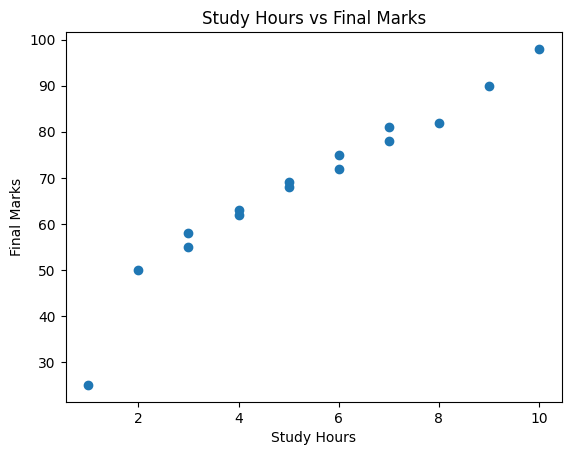

In [9]:
#Create a scatter plot to visualize the relationship between study hours an final marks
plt.scatter(df['Study_Hours'], df['Final_Marks'])
plt.xlabel('Study Hours')
plt.ylabel('Final Marks')
plt.title('Study Hours vs Final Marks')
plt.show()

Step7:Calculate Covariance

In [10]:
#Calculate covariance between study hours and final marks
#Display the covariance
covariance = df['Study_Hours'].cov(df['Final_Marks'])
print("covariance:", covariance)

covariance: 44.14285714285714


Step8:Calculate covariance Matrix

In [11]:
#Select the numerical columns for covariance analysis.
numerical_columns = df.select_dtypes(include=['number'])
#Calculate the covariance matrix
covariance_matrix = numerical_columns.cov()
covariance_matrix

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
Student_Id,2.000000e+01,2.857143,-1.015061e-15,8.857143,10.214286
Study_Hours,2.857143e+00,6.666667,3.259524e+01,36.000000,44.142857
Attendance,-1.015061e-15,32.595238,1.882095e+02,195.328571,239.685714
Assignment_Score,8.857143e+00,36.000000,1.953286e+02,210.257143,257.328571
Final_Marks,1.021429e+01,44.142857,2.396857e+02,257.328571,315.400000


Step9:Detect Outliers Using IQR

In [12]:
#select the final marks column for outlier analysis.
final_marks = df['Final_Marks']
#Calculate the IQR
Q1 = final_marks.quantile(0.25)
Q2 = final_marks.quantile(0.50)
Q3 = final_marks.quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 60.0
Q2: 69.0
Q3: 79.5
IQR: 19.5


Step10:Identify Outliers

In [13]:
#Identify outliers.
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR
print("Lower Bound:", Lower_Bound)
print("Upper Bound:", Upper_Bound)
#Select records where final marks are below the lower bound or above the upper bound.
outliers = df[(df['Final_Marks'] < Lower_Bound) | (df['Final_Marks'] > Upper_Bound)]
outliers

Lower Bound: 30.75
Upper Bound: 108.75


,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
14,115,1,40,35,25


Step11:Count Outliers

In [14]:
#Count the total number of detected outliers.
total_outliers = len(outliers)
total_outliers

1

Step12:Visualize Outliers Using Box Plot

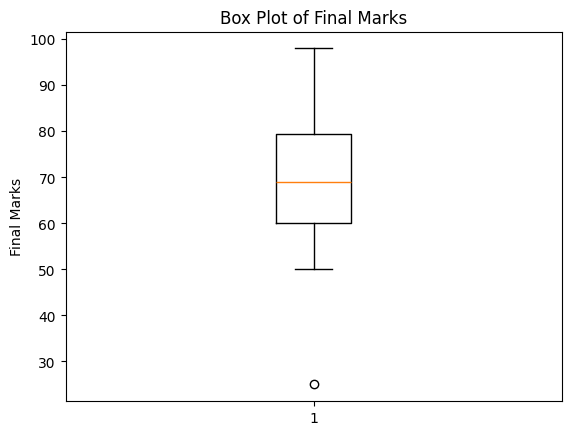

In [15]:
#Visualize outliers using box plot
plt.boxplot(df['Final_Marks'])
plt.ylabel('Final Marks')
plt.title('Box Plot of Final Marks')
plt.show()

Step13:Create a Histogram

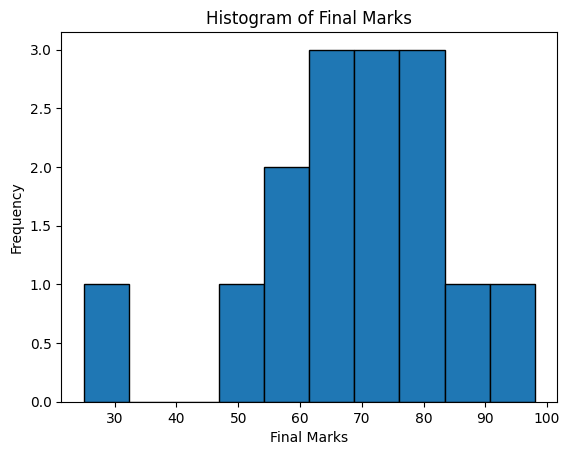

In [16]:
#Create a histogram to observe the distribution of final marks.
plt.hist(df['Final_Marks'], bins=10, edgecolor='black')
plt.xlabel('Final Marks')
plt.ylabel('Frequency')
plt.title('Histogram of Final Marks')
plt.show()

Step14: Analyze Distribution Using Skewness

In [17]:
#Calculate the skewness of final marks.
skewness = df['Final_Marks'].skew()
#Display the skewness value.
print("skewness:", skewness)

skewness: -0.7383380071904277


Step15:Calculate kurtosis

In [18]:
#Calculate the kurtosis of final marks.
kurtosis = df['Final_Marks'].kurtosis()
#Display the kurtosis value.
print("kurtosis:", kurtosis)

kurtosis: 1.4936683306648835


Step16:Distribution of Study Hours

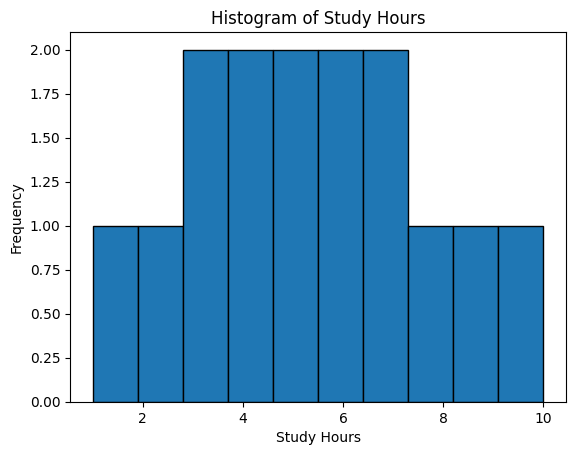

In [19]:
#Create a histogram for Study Hours.
plt.hist(df['Study_Hours'], bins=10, edgecolor='black')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.title('Histogram of Study Hours')
plt.show()

Step17:Compare Variables Using Box Plots

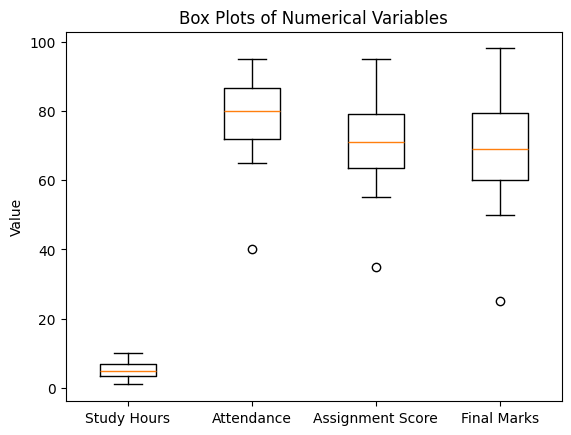

In [20]:
#Create box plots for multiple numerical variables.
plt.boxplot([df['Study_Hours'], df['Attendance'], df['Assignment_Score'], df['Final_Marks']])
plt.xticks([1, 2, 3, 4], ['Study Hours', 'Attendance', 'Assignment Score', 'Final Marks'])
plt.ylabel('Value')
plt.title('Box Plots of Numerical Variables')
plt.show()

Step18:Generate a Statistical Summary

In [21]:
#Generate a statistical summary.
summary = df.describe()
summary

,Student_Id,Study_Hours,Attendance,Assignment_Score,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,5.333333,77.733333,70.400000,68.400000
std,4.472136,2.581989,13.718948,14.500246,17.759504
min,101.000000,1.000000,40.000000,35.000000,25.000000
25%,104.500000,3.500000,72.000000,63.500000,60.000000
50%,108.000000,5.000000,80.000000,71.000000,69.000000
75%,111.500000,7.000000,86.500000,79.000000,79.500000
max,115.000000,10.000000,95.000000,95.000000,98.000000


Step19:Save the Analysis Dataset

In [22]:
#Save the analysis datset.
df.to_csv('Analysis_dataset.csv', index=False)
print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.


Step20:Download the CSV in Google Colab

In [23]:
# Download the CSV in Google Colab.
from google.colab import files
files.download('Analysis_dataset.csv')
print("Analysis dataset downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Analysis dataset downloaded successfully.
